In [1]:
import requests
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

csv_filename = "st2_weather_data.csv"

In [6]:
locations = [
    {"name": "Ho thuy dien", "lat": 15.325977, "lon": 108.112874},
    {"name": "Ngoc Linh - Thuong nguon", "lat": 15.068294, "lon": 107.975046},
    {"name": "Nam Tra My - Up stream", "lat": 15.192662, "lon": 108.116934},
    {"name": "Tra Leng - Nhanh song", "lat": 15.271991, "lon": 108.015098},
]

# Các biến cần lấy
hourly_params = "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,cloud_cover_mid,pressure_msl,soil_moisture_0_to_7cm"

all_points_data = []

print(f"Đang load data từ {START_DATE} đến {END_DATE}...")

for loc in locations:
    print(f"{loc['name']} ({loc['lat']}, {loc['lon']}) done..")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": loc["lat"],
        "longitude": loc["lon"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": hourly_params,
        "timezone": "Asia/Bangkok"
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        all_points_data.append(response.json().get("hourly", {}))
    else:
        print(f"Lỗi khi load điểm {loc['name']}: Error code {response.status_code}")

print("Done")

if len(all_points_data) == len(locations):
    # Lấy mốc thời gian từ điểm đầu tiên
    times = all_points_data[0].get("time", [])

    # Danh sách các key dữ liệu cần tính trung bình
    keys_to_average = [
        "temperature_2m", "relative_humidity_2m", "precipitation", 
        "wind_speed_10m", "wind_direction_10m", "cloud_cover_mid", 
        "pressure_msl", "soil_moisture_0_to_7cm"
    ]
    
    with open(csv_filename, mode='w', newline='', encoding='utf-8-sig') as file:
        writer = csv.writer(file)
        
        writer.writerow([
            "Time", "Temperature (°C)", "Humidity (%)", "Precipitations (mm)", 
            "Wind_speeds (km/h)", "Wind_direction (°)", "Cloud_cover_mid (%)", 
            "Pressure (hPa)", "Soil_moisture_0_7cm (m³/m³)"
        ])

        for i in range(len(times)):
            row_data = [times[i]]
            
            for key in keys_to_average:
                # Lấy giá trị của cùng 1 giờ từ tất cả các điểm, bỏ các giá trị None
                values = []
                for point_data in all_points_data:
                    val = point_data.get(key, [])
                    if i < len(val) and val[i] is not None:
                        values.append(val[i])

                if values:
                    avg_val = round(sum(values) / len(values), 2)
                    row_data.append(avg_val)
                else:
                    row_data.append("N/A") # Nếu cả tất cả đều None
            
            writer.writerow(row_data)
    print(f"Đã lưu vào file: {csv_filename}")
else:
    print("Không đủ data từ các điểm đo. Pls check ur API")

Đang load data từ 2022-01-01 đến 2025-12-31...
Ho thuy dien (15.325977, 108.112874) done..
Ngoc Linh - Thuong nguon (15.068294, 107.975046) done..
Nam Tra My - Up stream (15.192662, 108.116934) done..
Tra Leng - Nhanh song (15.271991, 108.015098) done..
Done
Đã lưu vào file: st2_weather_data.csv


In [7]:
df = pd.read_csv(csv_filename)
df = df.replace("N/A", pd.NA)

df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

df = df.astype(float)

print(f"Tổng số dòng dữ liệu: {len(df)}")
display(df.head())

Tổng số dòng dữ liệu: 35064


,Temperature (°C),Humidity (%),Precipitations (mm),Wind_speeds (km/h),Wind_direction (°),Cloud_cover_mid (%),Pressure (hPa),Soil_moisture_0_7cm (m³/m³)
Time,,,,,,,,
2022-01-01 00:00:00,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.5
2022-01-01 01:00:00,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.5
2022-01-01 02:00:00,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.5
2022-01-01 03:00:00,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.5
2022-01-01 04:00:00,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.5


In [8]:
df.describe()

,Temperature (°C),Humidity (%),Precipitations (mm),Wind_speeds (km/h),Wind_direction (°),Cloud_cover_mid (%),Pressure (hPa),Soil_moisture_0_7cm (m³/m³)
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,21.336908,86.815345,0.404807,4.848066,157.299096,24.888932,1012.498214,0.462356
std,3.737377,11.468533,1.053005,2.351437,69.441850,28.623992,4.693785,0.047250
min,9.930000,31.750000,0.000000,0.420000,9.500000,0.000000,990.750000,0.270000
25%,19.000000,80.500000,0.000000,3.120000,102.500000,2.250000,1009.030000,0.440000
50%,21.200000,90.500000,0.050000,4.320000,174.250000,13.000000,1012.220000,0.480000
75%,23.620000,95.750000,0.300000,6.100000,214.750000,38.000000,1015.900000,0.500000
max,34.850000,100.000000,27.200000,22.080000,357.750000,100.000000,1027.280000,0.520000


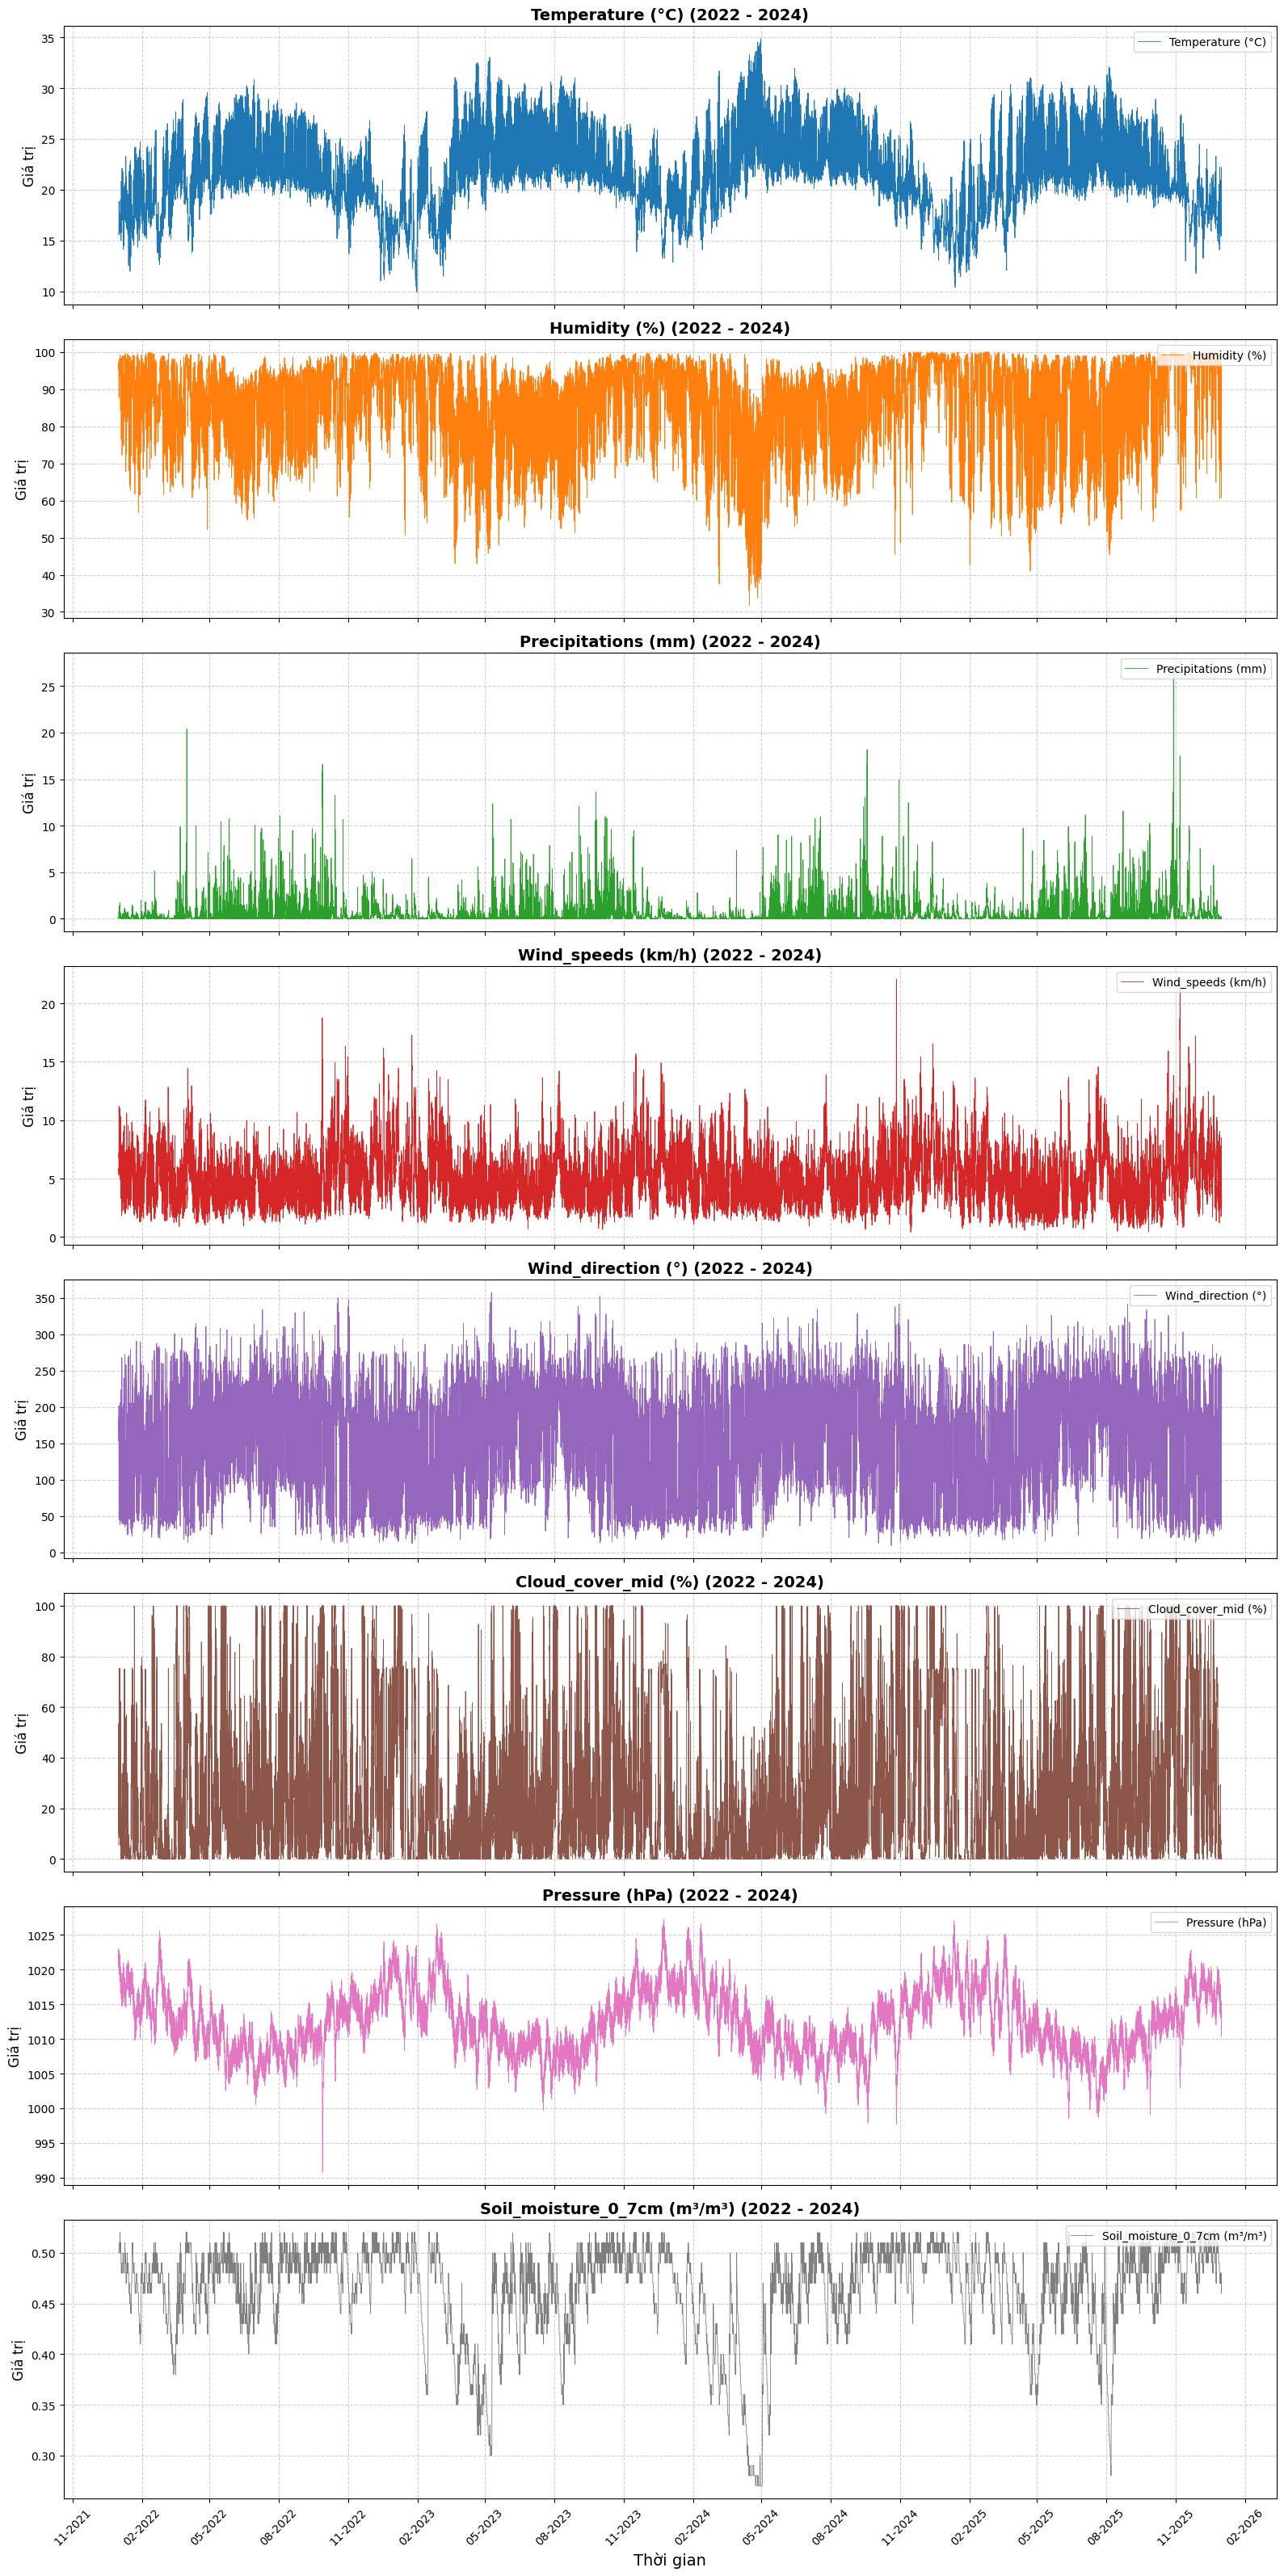

In [9]:
features = df.columns
num_features = len(features)

fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(16, 4 * num_features), sharex=True)
fig.subplots_adjust(hspace=0.3)

for i, feature in enumerate(features):
    ax = axes[i]
    ax.plot(df.index, df[feature], label=feature, color=plt.cm.tab10(i % 10), linewidth=0.6)
    
    ax.set_title(f'{feature} (2022 - 2024)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Giá trị', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))

plt.xlabel('Thời gian', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()